
---LOADING ADULT DATASET---

Dataset shape: (48842, 14)

---DETERMINING PREPROCESSED FEATURE DIMENSION---

Total features after preprocessing: 122
K values tested: [50, 100]

---BASELINE CROSS-VALIDATION---


Running baseline: Logistic Regression
F1: 0.6744 +/- 0.0049
ROC AUC: 0.9135
Time: 10.82 seconds

Running baseline: Random Forest
F1: 0.6683 +/- 0.0059
ROC AUC: 0.9013
Time: 22.32 seconds

---FEATURE SELECTION EXPERIMENTS---


Logistic Regression | SelectKBest k=50
F1: 0.6606 +/- 0.0044
ROC AUC: 0.9101
Time: 76.64 seconds

Logistic Regression | SelectKBest k=100
F1: 0.6717 +/- 0.0065
ROC AUC: 0.9130
Time: 62.20 seconds

Random Forest | SelectKBest k=50
F1: 0.6633 +/- 0.0063
ROC AUC: 0.8982
Time: 45.41 seconds

Random Forest | SelectKBest k=100
F1: 0.6695 +/- 0.0074
ROC AUC: 0.9006
Time: 69.23 seconds

---FEATURE SELECTION COMPARISON---

              Model      Selection   K  F1 Mean   F1 Std  ROC AUC Mean  ROC AUC Std  Accuracy Mean  Accuracy Std  Training Time Seconds
Logistic R

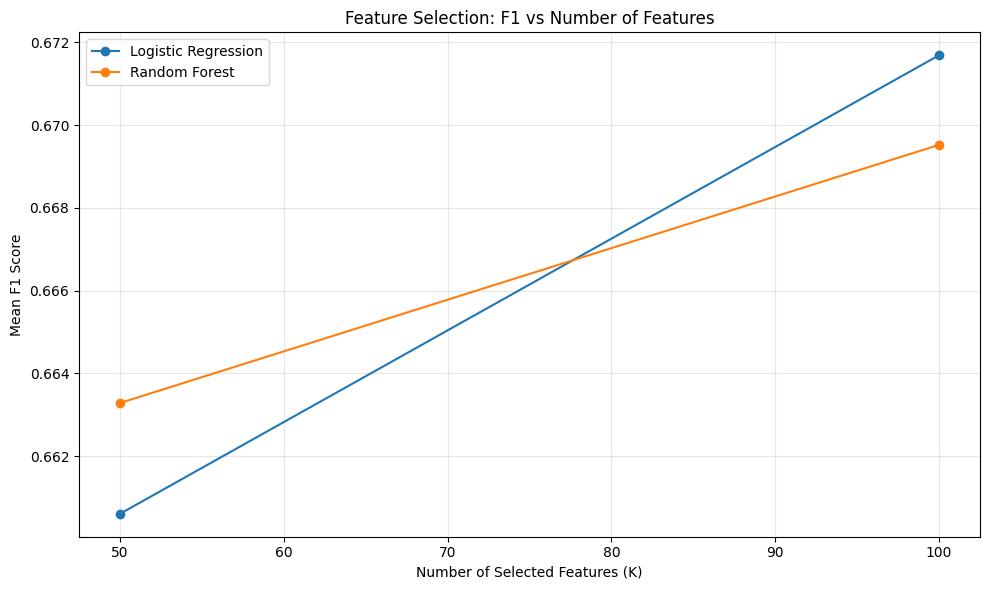

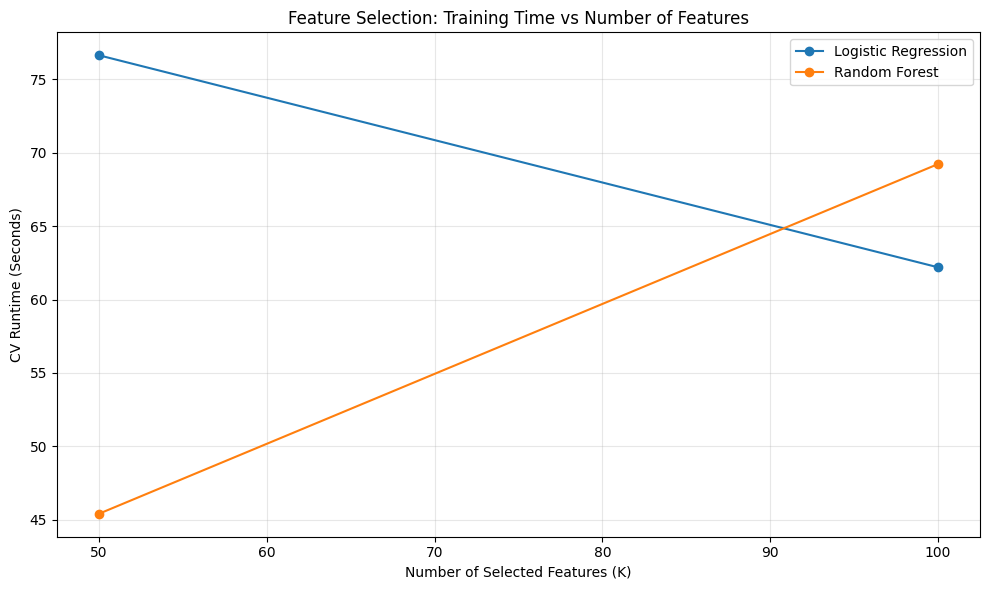


---RECOMMENDATION FOR TOMORROW'S HYPERPARAMETER TUNING---

Recommended model: Logistic Regression
Recommended number of features: K = 100
Recommended mean F1: 0.6717
Recommended ROC AUC: 0.9130
SelectKBest with Mutual Information gave the strongest observed F1 score among the tested settings.


In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

os.makedirs("../outputs", exist_ok=True)

print("\n---LOADING ADULT DATASET---\n")
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy().replace("?", np.nan)
df["target"] = df["class"].map({"<=50K": 0, ">50K": 1}).astype(int)
X = df.drop(columns=["class", "target"])
y = df["target"]
print("Dataset shape:", X.shape)


def create_engineered_features(data):
    data = data.copy()
    data["age_bucket"] = pd.cut(
        data["age"],
        bins=[0, 25, 35, 45, 55, 65, np.inf],
        labels=["Young", "Early_Career", "Mid_Career", "Experienced", "Senior", "Older"],
        include_lowest=True,
    )
    data["hours_bucket"] = pd.cut(
        data["hours-per-week"],
        bins=[0, 30, 40, 50, 60, np.inf],
        labels=["Part_Time", "Standard", "Overtime", "High_Hours", "Very_High_Hours"],
        include_lowest=True,
    )
    data["capital_gain_flag"] = (data["capital-gain"] > 0).astype(int)
    data["log_capital_gain"] = np.log1p(data["capital-gain"])
    data["higher_education"] = (data["education-num"] >= 13).astype(int)
    data["education_hours_interaction"] = data["education-num"] * data["hours-per-week"]
    data["capital_loss_flag"] = (data["capital-loss"] > 0).astype(int)
    data["age_hours_interaction"] = data["age"] * data["hours-per-week"]
    return data


feature_engineering = FunctionTransformer(create_engineered_features, validate=False)
numeric_features = [
    "age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week",
    "capital_gain_flag", "log_capital_gain", "higher_education",
    "education_hours_interaction", "capital_loss_flag", "age_hours_interaction",
]
categorical_features = [
    "workclass", "education", "marital-status", "occupation", "relationship",
    "race", "sex", "native-country", "age_bucket", "hours_bucket",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

models = {
    "Logistic Regression": LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"f1": "f1", "roc_auc": "roc_auc", "accuracy": "accuracy"}


def create_base_pipeline(model):
    return Pipeline([
        ("feature_engineering", feature_engineering),
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])


def create_selection_pipeline(model, k):
    return Pipeline([
        ("feature_engineering", feature_engineering),
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(score_func=mutual_info_classif, k=k)),
        ("classifier", model),
    ])


print("\n---DETERMINING PREPROCESSED FEATURE DIMENSION---\n")
temp_pipeline = Pipeline([
    ("feature_engineering", feature_engineering),
    ("preprocessor", preprocessor),
])
X_transformed = temp_pipeline.fit_transform(X, y)
total_features = X_transformed.shape[1]
print("Total features after preprocessing:", total_features)
k_values = [k for k in [50, 100, 150, 200] if k < total_features]
print("K values tested:", k_values)

baseline_results = []
print("\n---BASELINE CROSS-VALIDATION---\n")

for model_name, model in models.items():
    print(f"\nRunning baseline: {model_name}")
    start_time = time.perf_counter()
    scores = cross_validate(
        create_base_pipeline(model), X, y, cv=cv, scoring=scoring, n_jobs=-1,
    )
    elapsed = time.perf_counter() - start_time
    baseline_results.append({
        "Model": model_name,
        "Selection": "No Selection",
        "K": total_features,
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),
        "ROC AUC Mean": scores["test_roc_auc"].mean(),
        "ROC AUC Std": scores["test_roc_auc"].std(),
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Training Time Seconds": elapsed,
    })
    print(f"F1: {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f}")
    print(f"ROC AUC: {scores['test_roc_auc'].mean():.4f}")
    print(f"Time: {elapsed:.2f} seconds")

selection_results = []
print("\n---FEATURE SELECTION EXPERIMENTS---\n")
for model_name, model in models.items():
    for k in k_values:
        print(f"\n{model_name} | SelectKBest k={k}")
        start_time = time.perf_counter()
        scores = cross_validate(
            create_selection_pipeline(model, k), X, y, cv=cv, scoring=scoring, n_jobs=-1,
        )
        elapsed = time.perf_counter() - start_time
        selection_results.append({
            "Model": model_name,
            "Selection": "SelectKBest MI",
            "K": k,
            "F1 Mean": scores["test_f1"].mean(),
            "F1 Std": scores["test_f1"].std(),
            "ROC AUC Mean": scores["test_roc_auc"].mean(),
            "ROC AUC Std": scores["test_roc_auc"].std(),
            "Accuracy Mean": scores["test_accuracy"].mean(),
            "Accuracy Std": scores["test_accuracy"].std(),
            "Training Time Seconds": elapsed,
        })
        print(f"F1: {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f}")
        print(f"ROC AUC: {scores['test_roc_auc'].mean():.4f}")
        print(f"Time: {elapsed:.2f} seconds")

baseline_df = pd.DataFrame(baseline_results)
selection_df = pd.DataFrame(selection_results)
all_results = pd.concat([baseline_df, selection_df], ignore_index=True)
all_results = all_results.sort_values("F1 Mean", ascending=False).reset_index(drop=True)
print("\n---FEATURE SELECTION COMPARISON---\n")
print(all_results.to_string(index=False))
all_results.to_csv("../outputs/day3_task5_feature_selection_results.csv", index=False)

best_selection = selection_df.loc[selection_df["F1 Mean"].idxmax()]
same_model_baseline = baseline_df[baseline_df["Model"] == best_selection["Model"]].iloc[0]
f1_change = best_selection["F1 Mean"] - same_model_baseline["F1 Mean"]
time_change = best_selection["Training Time Seconds"] - same_model_baseline["Training Time Seconds"]
time_percentage = time_change / same_model_baseline["Training Time Seconds"] * 100


print("\n---BEST FEATURE SELECTION RESULT---\n")
print("Model:", best_selection["Model"])
print("Selected K:", int(best_selection["K"]))
print(f"F1: {best_selection['F1 Mean']:.4f} +/- {best_selection['F1 Std']:.4f}")
print(f"ROC AUC: {best_selection['ROC AUC Mean']:.4f}")
print(f"Training Time: {best_selection['Training Time Seconds']:.2f} seconds")

print("\n---BASELINE VS FEATURE SELECTION---\n")
print(f"Baseline F1: {same_model_baseline['F1 Mean']:.4f}")
print(f"Selected F1: {best_selection['F1 Mean']:.4f}")
print(f"F1 Change: {f1_change:+.4f}")
print(f"Baseline Time: {same_model_baseline['Training Time Seconds']:.2f}s")
print(f"Selected Time: {best_selection['Training Time Seconds']:.2f}s")
print(f"Time Change: {time_percentage:+.2f}%")

for metric, filename, ylabel, title in [
    ("F1 Mean", "day3_task5_f1_vs_features.png", "Mean F1 Score", "Feature Selection: F1 vs Number of Features"),
    ("Training Time Seconds", "day3_task5_time_vs_features.png", "CV Runtime (Seconds)", "Feature Selection: Training Time vs Number of Features"),
]:
    plt.figure(figsize=(10, 6))
    for model_name in models:
        model_data = selection_df[selection_df["Model"] == model_name].sort_values("K")
        plt.plot(model_data["K"], model_data[metric], marker="o", label=model_name)
    plt.xlabel("Number of Selected Features (K)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"../outputs/{filename}", dpi=300)
    plt.show()

print("\n---RECOMMENDATION FOR TOMORROW'S HYPERPARAMETER TUNING---\n")
print(f"Recommended model: {best_selection['Model']}")
print(f"Recommended number of features: K = {int(best_selection['K'])}")
print(f"Recommended mean F1: {best_selection['F1 Mean']:.4f}")
print(f"Recommended ROC AUC: {best_selection['ROC AUC Mean']:.4f}")
print("SelectKBest with Mutual Information gave the strongest observed F1 score among the tested settings.")